# 01 - Data Exploration

Explore the sports-impact metadata, class balance, feature relationships, and a few sampled video frames.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data.metadata import LABEL_ORDER, load_metadata
from src.data.video import sample_video_frames

sns.set_theme(style='whitegrid')

In [2]:
df = load_metadata(ROOT / 'data/metadata.csv', ROOT / 'data/cv_module_videos')
df.head()

,video_id,sport,impact_type,body_region,player_down,risk_level,video_path,label_id
0,VID_001,hockey,object_hit,head_face,yes,high,/Users/abigailreynolds/Desktop/AIPI_MEng/AIPI_...,2
1,VID_002,hockey,collision,upper_body,yes,moderate,/Users/abigailreynolds/Desktop/AIPI_MEng/AIPI_...,1
2,VID_003,hockey,collision,upper_body,yes,moderate,/Users/abigailreynolds/Desktop/AIPI_MEng/AIPI_...,1
3,VID_004,hockey,object_hit,head_face,yes,high,/Users/abigailreynolds/Desktop/AIPI_MEng/AIPI_...,2
4,VID_005,hockey,object_hit,head_face,yes,high,/Users/abigailreynolds/Desktop/AIPI_MEng/AIPI_...,2


In [3]:
df.shape, df['risk_level'].value_counts().reindex(LABEL_ORDER)

((93, 8),
 risk_level
 low         25
 moderate    37
 high        31
 Name: count, dtype: int64)

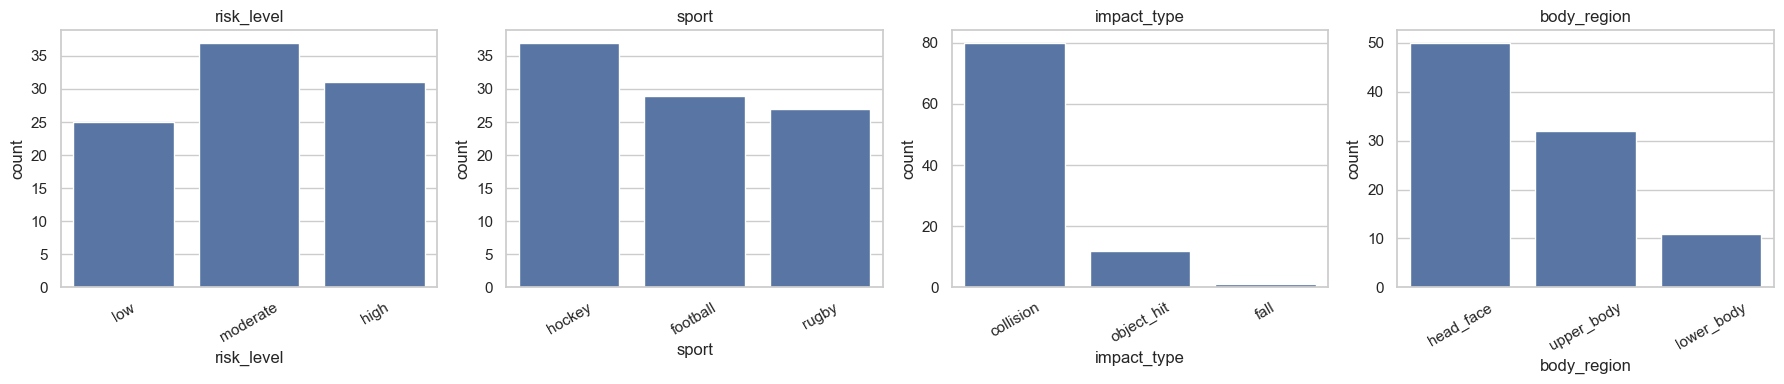

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ['risk_level', 'sport', 'impact_type', 'body_region']):
    order = LABEL_ORDER if col == 'risk_level' else df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
fig.tight_layout()

In [5]:
for col in ['sport', 'impact_type', 'body_region', 'player_down']:
    display(pd.crosstab(df[col], df['risk_level'], normalize='index')[LABEL_ORDER].round(3))

risk_level,low,moderate,high
sport,,,
football,0.448,0.379,0.172
hockey,0.054,0.297,0.649
rugby,0.370,0.556,0.074


risk_level,low,moderate,high
impact_type,,,
collision,0.3,0.388,0.312
fall,1.0,0.000,0.000
object_hit,0.0,0.500,0.500


risk_level,low,moderate,high
body_region,,,
head_face,0.000,0.400,0.600
lower_body,0.364,0.545,0.091
upper_body,0.656,0.344,0.000


risk_level,low,moderate,high
player_down,,,
no,1.000,0.000,0.000
yes,0.261,0.402,0.337


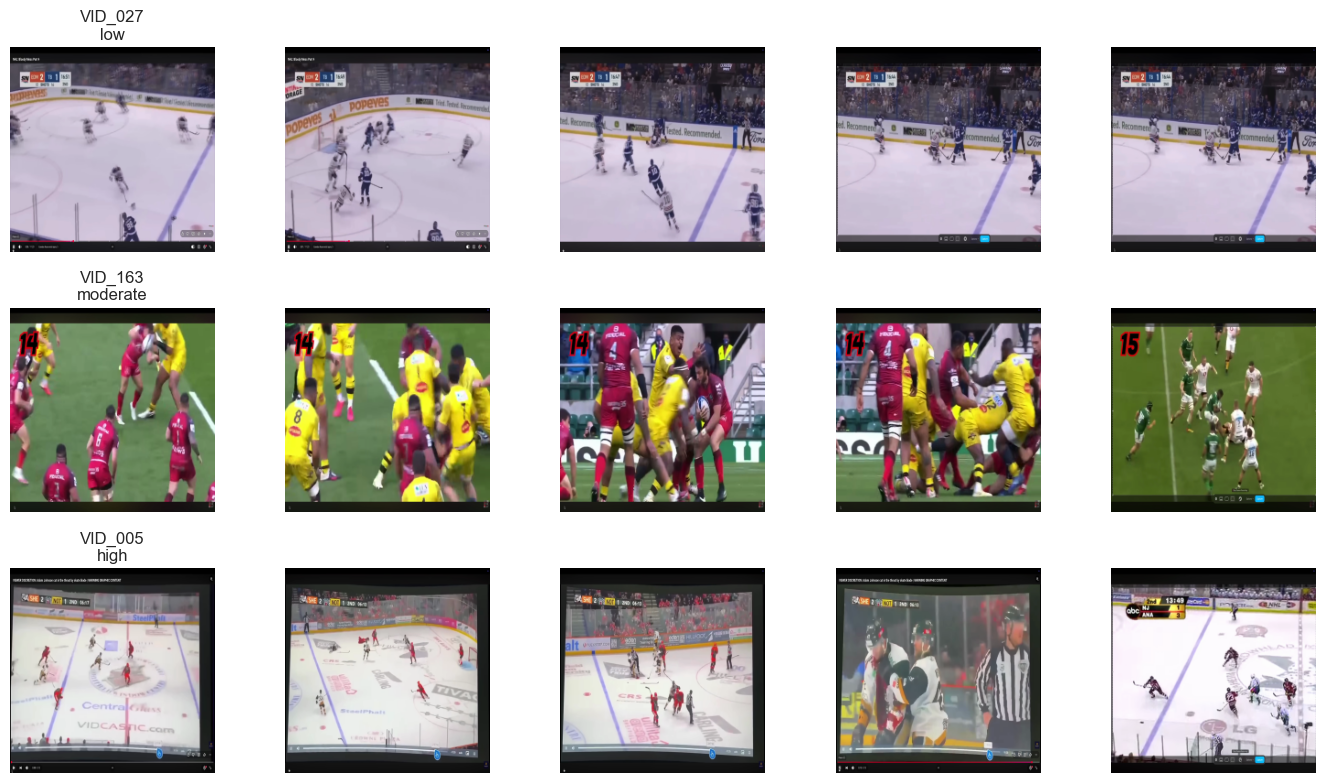

In [6]:
sample = pd.concat([
    df[df['risk_level'] == label].sample(1, random_state=7)
    for label in LABEL_ORDER
]).reset_index(drop=True)
fig, axes = plt.subplots(len(sample), 5, figsize=(14, 8))
for row_idx, row in sample.iterrows():
    frames = sample_video_frames(row['video_path'], num_frames=5, resize=(224, 224), rgb=True)
    for col_idx, frame in enumerate(frames):
        ax = axes[row_idx, col_idx]
        ax.imshow(frame)
        ax.axis('off')
        if col_idx == 0:
            ax.set_title(f"{row['video_id']}\n{row['risk_level']}")
fig.tight_layout()